In [1]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Flatten
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

In [2]:
# Load Fashion-MNIST dataset

(X_train, _), (_, _) = mnist.load_data()

print("Dataset shape:", X_train.shape)

Dataset shape: (60000, 28, 28)


In [3]:
# Normalize images to range [-1, 1]

X_train = (X_train.astype("float32") - 127.5) / 127.5

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)

print("New shape:", X_train.shape)

New shape: (60000, 28, 28, 1)


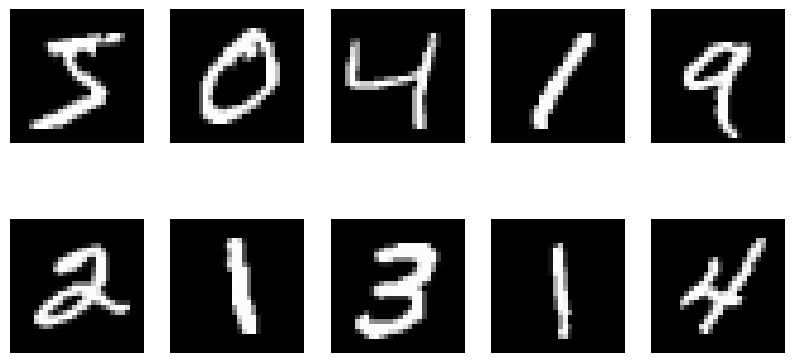

In [4]:
# Display sample images from dataset

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i].squeeze(), cmap="gray")

    plt.axis("off")

plt.show()

In [5]:
# Build Generator model
# Generator converts random noise into fake images

# Generator: noise vector -> 28x28 image

generator = Sequential([
    Dense(256, input_dim=100),
    LeakyReLU(0.2),
    BatchNormalization(),

    Dense(512),
    LeakyReLU(0.2),
    BatchNormalization(),

    Dense(1024),
    LeakyReLU(0.2),
    BatchNormalization(),

    Dense(28 * 28, activation="tanh"),
    Reshape((28, 28, 1))
])

generator.summary()

D:\рабочий стол DTI 2025\PycharmProjects1\NeuralNetworksLabs\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [6]:
# Build Discriminator model
# Discriminator tries to distinguish real and fake images

discriminator = Sequential([
    Flatten(input_shape=(28, 28, 1)),

    Dense(512),
    LeakyReLU(0.2),
    Dropout(0.3),

    Dense(256),
    LeakyReLU(0.2),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

discriminator.compile(
    optimizer=Adam(0.0001, 0.5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

discriminator.summary()

D:\рабочий стол DTI 2025\PycharmProjects1\NeuralNetworksLabs\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Build GAN model
# GAN combines Generator and Discriminator

discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer=Adam(0.0002, 0.5),
    loss="binary_crossentropy"
)

gan.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,025 (7.73 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 537,089 (2.05 MB)

In [8]:
# Define training parameters

epochs = 2000

batch_size = 128

noise_dim = 100

# Fixed noise is used to monitor the same generated images during training
fixed_noise = np.random.normal(0, 1, (16, noise_dim))

Epoch 0
Discriminator Loss: 0.5534
Discriminator Accuracy: 4.88%
Generator Loss: 0.5948


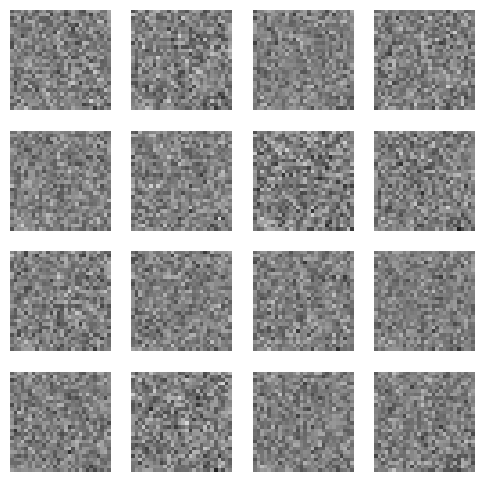

Epoch 100
Discriminator Loss: 0.2979
Discriminator Accuracy: 48.85%
Generator Loss: 2.5711
Epoch 200
Discriminator Loss: 0.2493
Discriminator Accuracy: 49.39%
Generator Loss: 3.8215
Epoch 300
Discriminator Loss: 0.2653
Discriminator Accuracy: 48.34%
Generator Loss: 3.5131
Epoch 400
Discriminator Loss: 0.3570
Discriminator Accuracy: 41.74%
Generator Loss: 2.9274
Epoch 500
Discriminator Loss: 0.4303
Discriminator Accuracy: 33.61%
Generator Loss: 2.4580


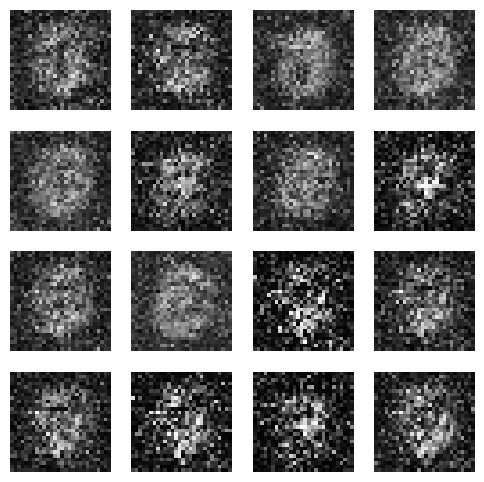

Epoch 600
Discriminator Loss: 0.4750
Discriminator Accuracy: 28.65%
Generator Loss: 2.1532
Epoch 700
Discriminator Loss: 0.5058
Discriminator Accuracy: 25.74%
Generator Loss: 1.9394
Epoch 800
Discriminator Loss: 0.5288
Discriminator Accuracy: 24.11%
Generator Loss: 1.7811
Epoch 900
Discriminator Loss: 0.5465
Discriminator Accuracy: 23.23%
Generator Loss: 1.6597
Epoch 1000
Discriminator Loss: 0.5601
Discriminator Accuracy: 22.76%
Generator Loss: 1.5635


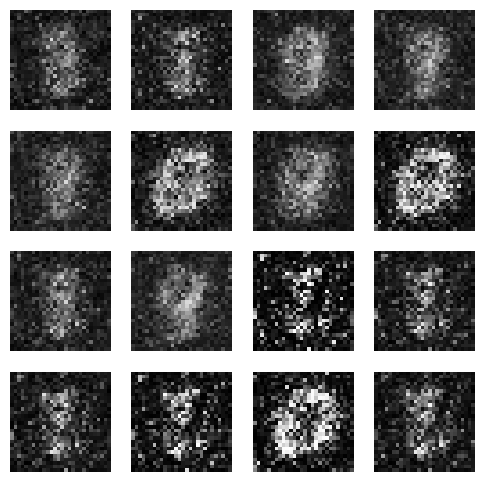

Epoch 1100
Discriminator Loss: 0.5712
Discriminator Accuracy: 22.73%
Generator Loss: 1.4865
Epoch 1200
Discriminator Loss: 0.5802
Discriminator Accuracy: 22.85%
Generator Loss: 1.4229
Epoch 1300
Discriminator Loss: 0.5875
Discriminator Accuracy: 23.16%
Generator Loss: 1.3704
Epoch 1400
Discriminator Loss: 0.5934
Discriminator Accuracy: 23.60%
Generator Loss: 1.3265
Epoch 1500
Discriminator Loss: 0.5981
Discriminator Accuracy: 24.11%
Generator Loss: 1.2896


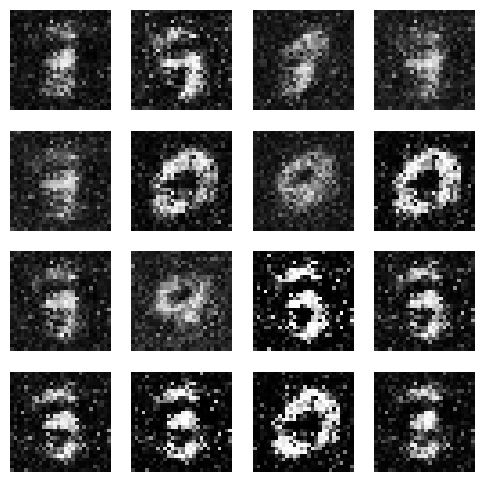

Epoch 1600
Discriminator Loss: 0.6025
Discriminator Accuracy: 24.63%
Generator Loss: 1.2580
Epoch 1700
Discriminator Loss: 0.6056
Discriminator Accuracy: 25.24%
Generator Loss: 1.2316
Epoch 1800
Discriminator Loss: 0.6086
Discriminator Accuracy: 25.75%
Generator Loss: 1.2088
Epoch 1900
Discriminator Loss: 0.6114
Discriminator Accuracy: 26.22%
Generator Loss: 1.1883


In [9]:
# Train GAN

for epoch in range(epochs):

    # Train Discriminator
    discriminator.trainable = True

    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_images = X_train[idx]

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_images = generator.predict(noise, verbose=0)

    real_labels = np.ones((batch_size, 1)) * 0.9
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    valid_labels = np.ones((batch_size, 1))

    g_loss = gan.train_on_batch(noise, valid_labels)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}")
        print(f"Discriminator Loss: {d_loss[0]:.4f}")
        print(f"Discriminator Accuracy: {d_loss[1] * 100:.2f}%")
        print(f"Generator Loss: {g_loss:.4f}")

    if epoch % 500 == 0:
        # Generate images from the same noise vector to monitor progress
        generated_images = generator.predict(fixed_noise, verbose=0)
        generated_images = generated_images.reshape(16, 28, 28)
        generated_images = (generated_images + 1) / 2

        plt.figure(figsize=(6, 6))

        for i in range(16):
            plt.subplot(4, 4, i + 1)
            plt.imshow(generated_images[i], cmap="gray", vmin=0, vmax=1)
            plt.axis("off")

        plt.show()

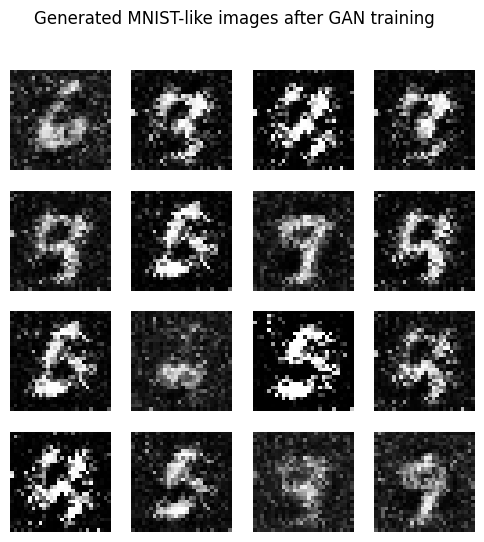

In [10]:
# Generate fake MNIST images

noise = np.random.normal(0, 1, (16, noise_dim))
generated_images = generator.predict(noise, verbose=0)

generated_images = generated_images.reshape(16, 28, 28)

# Convert from [-1, 1] to [0, 1]
generated_images = (generated_images + 1) / 2

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i], cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

plt.suptitle("Generated MNIST-like images after GAN training")
plt.show()

In [11]:
# Final conclusions about GAN training

print("GAN training completed successfully.")

print("\nThe Generator learned to create synthetic MNIST-like images from random noise.")

print("The Discriminator learned to distinguish between real handwritten digits and generated fake images.")

print("During the first training epochs, the generated images looked like random noise and unclear patterns.")

print("After increasing the number of epochs, the Generator gradually started producing digit-like shapes.")

print("GAN training is unstable and highly sensitive to model parameters, training time, and the balance between Generator and Discriminator.")

print("This lab demonstrates the concept of adversarial learning, where two neural networks compete and improve simultaneously.")

GAN training completed successfully.

The Generator learned to create synthetic MNIST-like images from random noise.
The Discriminator learned to distinguish between real handwritten digits and generated fake images.
During the first training epochs, the generated images looked like random noise and unclear patterns.
After increasing the number of epochs, the Generator gradually started producing digit-like shapes.
GAN training is unstable and highly sensitive to model parameters, training time, and the balance between Generator and Discriminator.
This lab demonstrates the concept of adversarial learning, where two neural networks compete and improve simultaneously.
